In [1]:
import pandas as pd
df1 = pd.read_csv("fear_greed_index.csv")

In [3]:
df2 = pd.read_csv("historical_data.csv")

In [7]:
df1.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [11]:
df1.count()

timestamp         2644
value             2644
classification    2644
date              2644
dtype: int64

In [13]:
df2.count()

Account             211224
Coin                211224
Execution Price     211224
Size Tokens         211224
Size USD            211224
Side                211224
Timestamp IST       211224
Start Position      211224
Direction           211224
Closed PnL          211224
Transaction Hash    211224
Order ID            211224
Crossed             211224
Fee                 211224
Trade ID            211224
Timestamp           211224
dtype: int64

DATA CLEANING

In [15]:
print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)

print("\nDataset 1 Info:")
print(df1.info())

print("\nDataset 2 Info:")
print(df2.info())

Dataset 1 Shape: (2644, 4)
Dataset 2 Shape: (211224, 16)

Dataset 1 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Dataset 2 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-nu

In [17]:
# Missing values
print("\nMissing Values (df1):")
print(df1.isnull().sum())

print("\nMissing Values (df2):")
print(df2.isnull().sum())

# Duplicates
print("\nDuplicates in df1:", df1.duplicated().sum())
print("Duplicates in df2:", df2.duplicated().sum())

# Optional: Remove duplicates
df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()


Missing Values (df1):
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (df2):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates in df1: 0
Duplicates in df2: 0


In [25]:
print(df1.columns)
print(df2.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


EDA

In [163]:
#Matching the datetime timestamp dor betterment for the code and model
df2['Timestamp IST'] = pd.to_datetime(df2['Timestamp IST'], format='%d-%m-%Y %H:%M')

df1['timestamp'] = pd.to_datetime(df1['timestamp'])
df2['Timestamp IST'] = pd.to_datetime(df2['Timestamp IST'])

df1['date'] = df1['timestamp'].dt.date
df2['date'] = df2['Timestamp IST'].dt.date

In [37]:
merged_df = pd.merge(df1, df2, on="date", how="inner")
print("Merged Shape:", merged_df.shape)

Merged Shape: (0, 20)


In [49]:
# Daily PnL
daily_pnl = df2.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()

# Trades per day
trades_per_day = df2.groupby('date').size().reset_index(name='num_trades')

# Long/Short ratio
long_short = df2['Side'].value_counts(normalize=True)

In [51]:
df2['win'] = df2['Closed PnL'] > 0

win_rate = df2.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

print(win_rate.head())

                                      Account  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914


In [53]:
avg_trade_size = df2.groupby('Account')['Size USD'].mean().reset_index()

print(avg_trade_size.head())

                                      Account      Size USD
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327
2  0x271b280974205ca63b716753467d5a371de622ab   8893.000898
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782


In [55]:
print("Leverage data not available in dataset")

Leverage data not available in dataset


In [57]:
trades_per_day = df2.groupby('date').size().reset_index(name='num_trades')

print(trades_per_day.head())

         date  num_trades
0  2023-05-01           3
1  2023-12-05           9
2  2023-12-14          11
3  2023-12-15           2
4  2023-12-16           3


In [61]:
long_short = df2['Side'].value_counts(normalize=True)

print(long_short)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


In [101]:
import pandas as pd
import matplotlib.pyplot as plt

df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

df1['timestamp'] = pd.to_datetime(df1['timestamp'], dayfirst=True)
df2['Timestamp IST'] = pd.to_datetime(df2['Timestamp IST'], dayfirst=True)
# Sort (VERY IMPORTANT for merge_asof)
df1 = df1.sort_values('timestamp')
df2 = df2.sort_values('Timestamp IST')
# Rename useful columns
df2.rename(columns={
    'Account': 'account',
    'Closed PnL': 'pnl',
    'Size USD': 'trade_size',
    'Side': 'side'
}, inplace=True)

In [103]:
merged = pd.merge_asof(
    df2,
    df1[['timestamp', 'classification']],
    left_on='Timestamp IST',
    right_on='timestamp',
    direction='nearest'
)

In [105]:
print("Merged shape:", merged.shape)
print(merged['classification'].value_counts())

Merged shape: (211224, 20)
classification
Greed    211224
Name: count, dtype: int64


In [107]:
merged['win'] = merged['pnl'] > 0

pnl_sentiment = merged.groupby('classification')['pnl'].mean()
win_rate_sentiment = merged.groupby('classification')['win'].mean()
drawdown = merged.groupby('classification')['pnl'].min()

print(pnl_sentiment)
print(win_rate_sentiment)
print(drawdown)

classification
Greed    48.749001
Name: pnl, dtype: float64
classification
Greed    0.411265
Name: win, dtype: float64
classification
Greed   -117990.1041
Name: pnl, dtype: float64


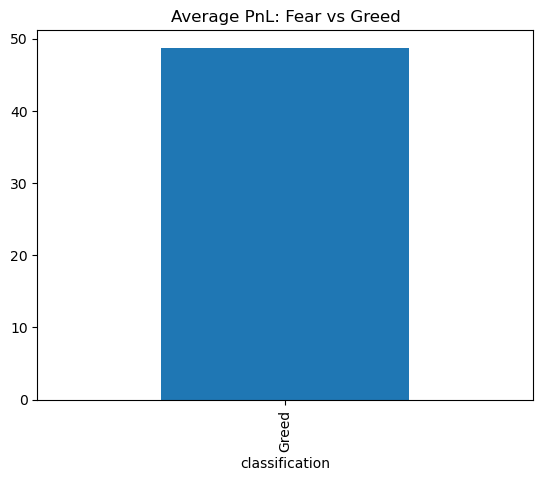

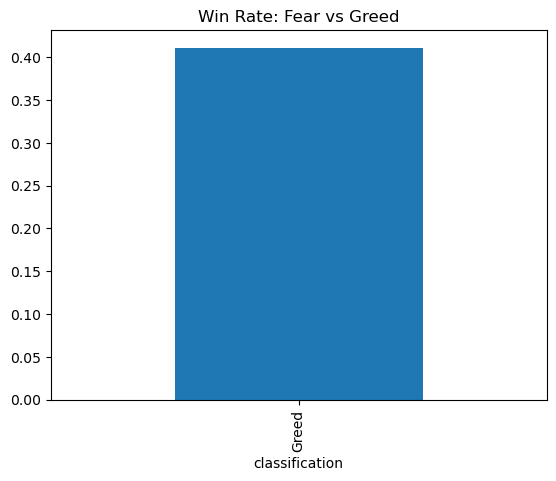

In [111]:
plt.figure()
pnl_sentiment.plot(kind='bar')
plt.title("Average PnL: Fear vs Greed")
plt.show()

plt.figure()
win_rate_sentiment.plot(kind='bar')
plt.title("Win Rate: Fear vs Greed")
plt.show()

In [113]:
merged['date'] = merged['Timestamp IST'].dt.date
trades = merged.groupby(['date', 'classification']).size().reset_index(name='trades')
avg_trades = trades.groupby('classification')['trades'].mean()

In [115]:
size_sentiment = merged.groupby('classification')['trade_size'].mean()

In [117]:
long_short = pd.crosstab(merged['classification'], merged['Side'], normalize='index')
print(long_short)

side                 BUY      SELL
classification                    
Greed           0.486195  0.513805


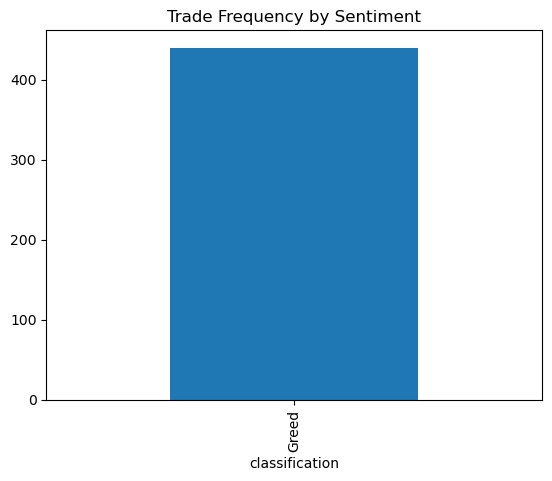

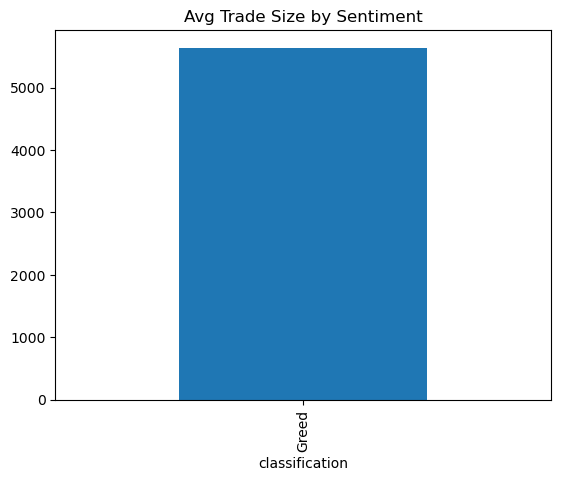

In [156]:
plt.figure()
avg_trades.plot(kind='bar')
plt.title("Trade Frequency by Sentiment")
plt.show()

plt.figure()
size_sentiment.plot(kind='bar')
plt.title("Avg Trade Size by Sentiment")
plt.show()

In [160]:
trade_counts = merged['account'].value_counts()
threshold = trade_counts.median()

merged['Trade ID'] = merged['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

segment_pnl = merged.groupby('trader_type')['pnl'].mean()

In [152]:
consistency = merged.groupby('account')['win'].mean()

merged['consistency_type'] = merged['account'].map(
    lambda x: 'Consistent' if consistency[x] > 0.6 else 'Inconsistent'
)

consistency_pnl = merged.groupby('consistency_type')['pnl'].mean()

plotting

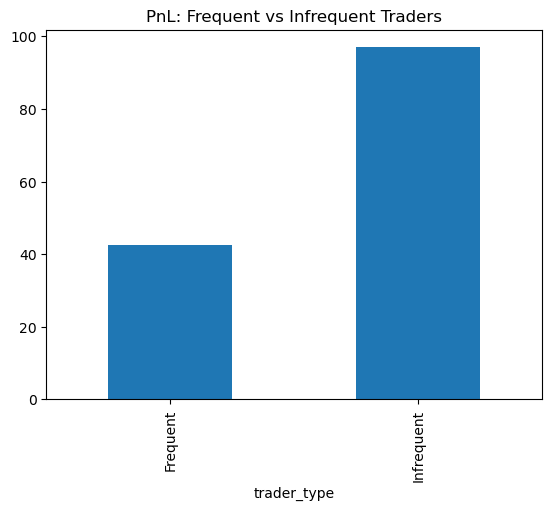

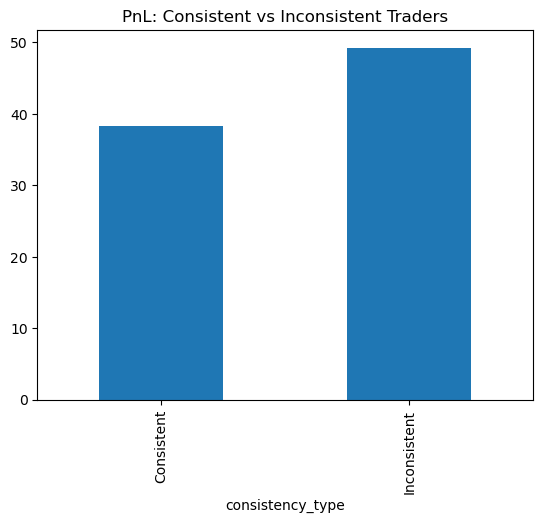

In [154]:
plt.figure()
segment_pnl.plot(kind='bar')
plt.title("PnL: Frequent vs Infrequent Traders")
plt.show()

plt.figure()
consistency_pnl.plot(kind='bar')
plt.title("PnL: Consistent vs Inconsistent Traders")
plt.show()

FEATURE ENGINEERing

In [127]:
import pandas as pd
merged['date'] = merged['Timestamp IST'].dt.date
features = merged.groupby(['account', 'date']).agg({
    'pnl': 'sum',
    'trade_size': 'mean',
    'side': 'count'
}).reset_index()
features.rename(columns={'side': 'num_trades'}, inplace=True)

features['next_day_pnl'] = features.groupby('account')['pnl'].shift(-1)

features['target'] = (features['next_day_pnl'] > 0).astype(int)

features.dropna(inplace=True)

TRAINING MODEL

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = features[['pnl', 'trade_size', 'num_trades']]
y = features['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6471861471861472


SENTIMENT

In [131]:
merged['sentiment'] = merged['classification'].map({'Fear': 0, 'Greed': 1})

sentiment_daily = merged.groupby(['account','date'])['sentiment'].mean().reset_index()

features = features.merge(sentiment_daily, on=['account','date'])

CLUSTERING

In [133]:
from sklearn.cluster import KMeans

trader_features = merged.groupby('account').agg({
    'pnl': 'mean',
    'trade_size': 'mean',
    'win': 'mean'
}).reset_index()

kmeans = KMeans(n_clusters=3, random_state=0)
trader_features['cluster'] = kmeans.fit_predict(
    trader_features[['pnl', 'trade_size', 'win']]
)

print(trader_features.head())

                                      account         pnl    trade_size  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  16159.576734   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654   1653.226327   
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043   8893.000898   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530    507.626933   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011   3138.894782   

        win  cluster  
0  0.359612        2  
1  0.442720        0  
2  0.301917        0  
3  0.438585        0  
4  0.519914        0  


D:\Anaconda_Install\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
